In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 11,
    "axes.titlesize": 13,
})

np.random.seed(42)
torch.manual_seed(42)

print("Ready.")

Ready.


---
# 1) Residual Connections

Residual connections (He et al., 2015) are arguably the single most important architectural innovation for training very deep networks.

---

## 1.1 The Degradation Problem (Deeper ≠ Better Without Residuals)

A surprising empirical observation: adding more layers to a plain network can **increase** both training and test error. This is **not** overfitting (training error also increases!) — it's an optimization problem.

The deeper network has a strictly larger hypothesis space (it could learn the identity for extra layers), yet SGD fails to find a good solution due to vanishing/exploding gradients and increasingly difficult optimization landscapes.

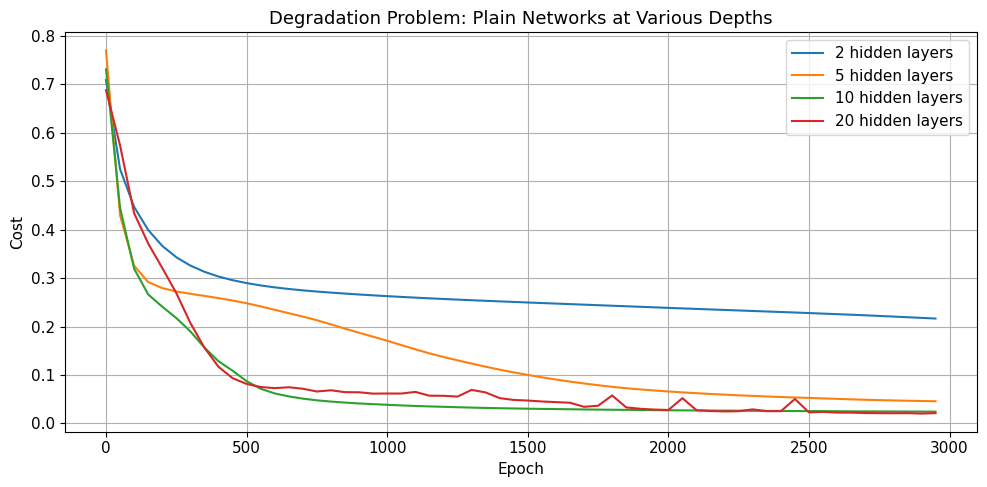

Deeper plain networks train WORSE — this is the degradation problem.


In [ ]:
def make_classification_data(num_samples=500):
    """Synthetic 2D classification data."""
    X, y = make_moons(n_samples=num_samples, noise=0.2, random_state=42)
    return X.T, y.reshape(1, -1)


def train_plain_network(num_hidden_layers, hidden_dim=20, epochs=3000, lr=0.01):
    """Train a plain (no residual) network and return cost history."""
    X, Y = make_classification_data()
    dims = [2] + [hidden_dim] * num_hidden_layers + [1]
    net = L2RegularizedNetwork(dims, lambd=0.0)
    costs = []
    for epoch in range(epochs):
        A = net.forward(X)
        cost = net.compute_cost(A, Y)
        grads = net.backward(Y)
        net.update_params(grads, lr)
        if epoch % 50 == 0:
            costs.append(cost)
    return costs


# Compare training curves for different depths
fig, ax = plt.subplots(figsize=(10, 5))
for n_layers in [2, 5, 10, 20]:
    np.random.seed(42)
    costs = train_plain_network(n_layers, hidden_dim=20, epochs=3000, lr=0.01)
    ax.plot(np.arange(len(costs)) * 50, costs, label=f"{n_layers} hidden layers")

ax.set_xlabel("Epoch")
ax.set_ylabel("Cost")
ax.set_title("Degradation Problem: Plain Networks at Various Depths")
ax.legend()
plt.tight_layout()
plt.show()
print("Deeper plain networks train WORSE — this is the degradation problem.")

## 1.2 Implementation

In [ ]:
class ResBlock:
    """Post-activation residual block: x → Linear → ReLU → Linear → + x → ReLU."""

    def __init__(self, dim):
        scale = np.sqrt(2.0 / dim)
        # (dim, dim)
        self.W1 = np.random.randn(dim, dim) * scale
        self.b1 = np.zeros((dim, 1))
        # (dim, dim)
        self.W2 = np.random.randn(dim, dim) * scale
        self.b2 = np.zeros((dim, 1))
        self.cache = {}

    def forward(self, X):
        """Forward pass through the residual block."""
        # (dim, batch_num)
        self.cache["X"] = X

        # First linear + ReLU
        # (dim, batch_num)
        Z1 = self.W1 @ X + self.b1
        A1 = np.maximum(0, Z1)
        self.cache["Z1"], self.cache["A1"] = Z1, A1

        # Second linear
        # (dim, batch_num)
        Z2 = self.W2 @ A1 + self.b2
        self.cache["Z2"] = Z2

        # Skip connection + ReLU
        # (dim, batch_num)
        out = np.maximum(0, Z2 + X)
        self.cache["out"] = out
        return out

    def backward(self, dout):
        """Backward pass through the residual block."""
        batch_num = dout.shape[1]

        # Gradient through output ReLU
        # (dim, batch_num)
        d_pre_relu = dout * (self.cache["out"] > 0).astype(float)

        # Skip connection: gradient flows to both Z2 and X
        dZ2 = d_pre_relu
        dX_skip = d_pre_relu

        # Backprop through second linear layer
        # (dim, dim)
        self.dW2 = (1 / batch_num) * (dZ2 @ self.cache["A1"].T)
        self.db2 = (1 / batch_num) * np.sum(dZ2, axis=1, keepdims=True)
        # (dim, batch_num)
        dA1 = self.W2.T @ dZ2

        # Backprop through first ReLU
        dZ1 = dA1 * (self.cache["Z1"] > 0).astype(float)

        # Backprop through first linear layer
        self.dW1 = (1 / batch_num) * (dZ1 @ self.cache["X"].T)
        self.db1 = (1 / batch_num) * np.sum(dZ1, axis=1, keepdims=True)
        dX_main = self.W1.T @ dZ1

        # Total gradient to input: residual path + skip path
        # (dim, batch_num)
        dX = dX_main + dX_skip
        return dX

    def update(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2


# Quick test
np.random.seed(0)
block = ResBlock(dim=8)
# (8, 4)
X_test = np.random.randn(8, 4)
out = block.forward(X_test)
print(f"Input shape:  {X_test.shape}")
print(f"Output shape: {out.shape}")

# Verify gradient flow
dout = np.random.randn(*out.shape)
dX = block.backward(dout)
print(f"dX shape:     {dX.shape}")
print(f"Max |dX|:     {np.abs(dX).max():.4f} (skip connection prevents vanishing)")

Input shape:  (8, 4)
Output shape: (8, 4)
dX shape:     (8, 4)
Max |dX|:     5.1634 (skip connection prevents vanishing)


---
## 1.3 Pre-activation vs Post-activation ResBlock

**Post-activation** (original ResNet):
$$y = \text{ReLU}({F}(x) + x), \quad {F}(x) = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2$$

**Pre-activation** (He et al., 2016):
$$y = {F}(x) + x, \quad {F}(x) = W_2 \cdot \text{ReLU}(\text{BN}(W_1 \cdot \text{ReLU}(\text{BN}(x))))$$

The pre-activation variant moves BN and ReLU **before** the weight layers. Key advantage: the skip connection is a **clean identity** without any activation gating, yielding strictly better gradient flow:

$$\frac{\partial x_{l+1}}{\partial x_l} = I + \frac{\partial {F}}{\partial x_l}$$

In post-activation, the final ReLU can zero out gradients; in pre-activation, the identity shortcut is unobstructed.

In [ ]:
class PreActResBlock:
    """Pre-activation residual block: BN → ReLU → Linear → BN → ReLU → Linear → + x.

    Simplified: we skip BN and just do ReLU → Linear → ReLU → Linear → + x.
    """

    def __init__(self, dim):
        scale = np.sqrt(2.0 / dim)
        self.W1 = np.random.randn(dim, dim) * scale
        self.b1 = np.zeros((dim, 1))
        self.W2 = np.random.randn(dim, dim) * scale
        self.b2 = np.zeros((dim, 1))
        self.cache = {}

    def forward(self, X):
        self.cache["X"] = X

        # Pre-activation: ReLU before first linear
        # (dim, batch_num)
        R1 = np.maximum(0, X)
        Z1 = self.W1 @ R1 + self.b1
        self.cache["R1"], self.cache["Z1"] = R1, Z1

        # Pre-activation: ReLU before second linear
        # (dim, batch_num)
        R2 = np.maximum(0, Z1)
        Z2 = self.W2 @ R2 + self.b2
        self.cache["R2"], self.cache["Z2"] = R2, Z2

        # Clean identity shortcut — no activation on top
        # (dim, batch_num)
        out = Z2 + X
        return out

    def backward(self, dout):
        batch_num = dout.shape[1]

        # No ReLU gate at output — gradient passes through cleanly
        dZ2 = dout
        dX_skip = dout

        self.dW2 = (1 / batch_num) * (dZ2 @ self.cache["R2"].T)
        self.db2 = (1 / batch_num) * np.sum(dZ2, axis=1, keepdims=True)
        dR2 = self.W2.T @ dZ2

        dZ1 = dR2 * (self.cache["Z1"] > 0).astype(float)
        self.dW1 = (1 / batch_num) * (dZ1 @ self.cache["R1"].T)
        self.db1 = (1 / batch_num) * np.sum(dZ1, axis=1, keepdims=True)
        dR1 = self.W1.T @ dZ1

        dX_main = dR1 * (self.cache["X"] > 0).astype(float)

        # (dim, batch_num)
        return dX_main + dX_skip

    def update(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2


print("PreActResBlock defined. Clean identity shortcut for superior gradient flow.")

PreActResBlock defined. Clean identity shortcut for superior gradient flow.


---
## 1.4 Experiment

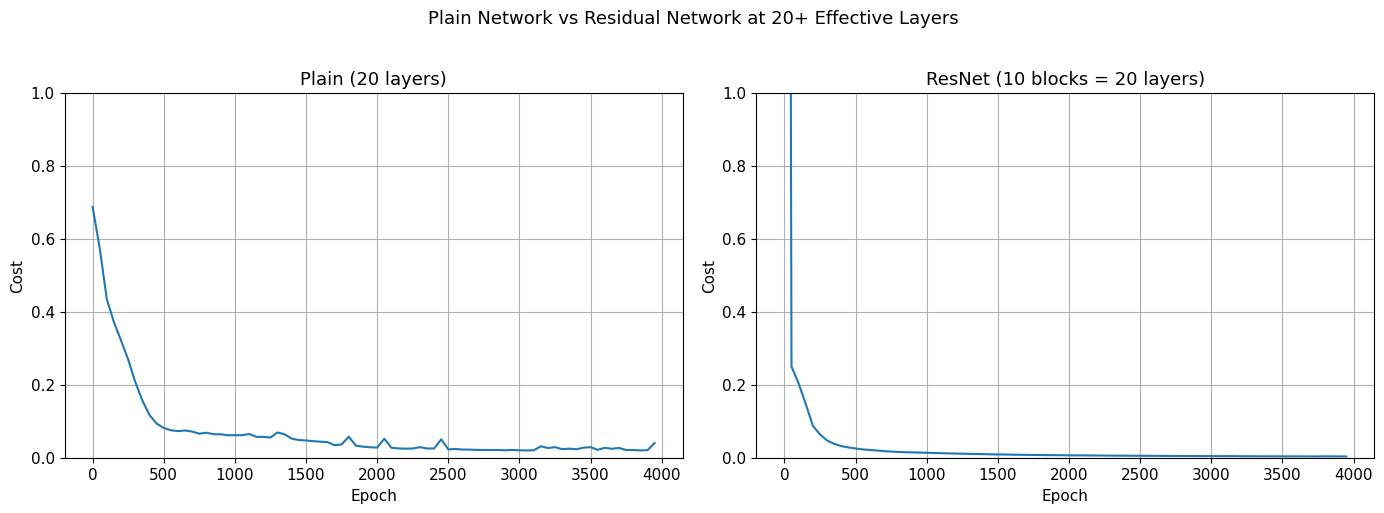

In [ ]:
class ResidualNetwork:
    """Deep network composed of a projection layer, stacked ResBlocks, and output layer."""

    def __init__(self, input_dim, hidden_dim, num_blocks, output_dim):
        self.num_blocks = num_blocks
        scale = np.sqrt(2.0 / input_dim)

        # Projection from input_dim to hidden_dim
        # (hidden_dim, input_dim)
        self.W_in = np.random.randn(hidden_dim, input_dim) * scale
        self.b_in = np.zeros((hidden_dim, 1))

        # Stacked residual blocks
        self.blocks = [ResBlock(hidden_dim) for _ in range(num_blocks)]

        # Output projection
        scale_out = np.sqrt(2.0 / hidden_dim)
        # (output_dim, hidden_dim)
        self.W_out = np.random.randn(output_dim, hidden_dim) * scale_out
        self.b_out = np.zeros((output_dim, 1))

    def forward(self, X):
        # (hidden_dim, batch_num)
        H = np.maximum(0, self.W_in @ X + self.b_in)
        self.cache_X = X
        self.cache_H_in = H

        for block in self.blocks:
            H = block.forward(H)

        # (output_dim, batch_num)
        Z = self.W_out @ H + self.b_out
        A = 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))
        self.cache_H_final = H
        self.cache_A_out = A
        return A

    def backward(self, Y):
        batch_num = Y.shape[1]
        # (output_dim, batch_num)
        dZ_out = self.cache_A_out - Y

        self.dW_out = (1 / batch_num) * (dZ_out @ self.cache_H_final.T)
        self.db_out = (1 / batch_num) * np.sum(dZ_out, axis=1, keepdims=True)
        dH = self.W_out.T @ dZ_out

        for block in reversed(self.blocks):
            dH = block.backward(dH)

        dH_in = dH * (self.cache_H_in > 0).astype(float)
        self.dW_in = (1 / batch_num) * (dH_in @ self.cache_X.T)
        self.db_in = (1 / batch_num) * np.sum(dH_in, axis=1, keepdims=True)

    def update(self, lr):
        self.W_in -= lr * self.dW_in
        self.b_in -= lr * self.db_in
        self.W_out -= lr * self.dW_out
        self.b_out -= lr * self.db_out
        for block in self.blocks:
            block.update(lr)


X_exp, Y_exp = make_classification_data(500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare: plain deep net vs residual net (both ~20 layers effective depth)
for ax, (label, use_res) in zip(axes, [("Plain (20 layers)", False), ("ResNet (10 blocks = 20 layers)", True)]):
    np.random.seed(42)
    if use_res:
        net = ResidualNetwork(input_dim=2, hidden_dim=20, num_blocks=10, output_dim=1)
        costs = []
        for epoch in range(4000):
            A = net.forward(X_exp)
            cost = -np.mean(Y_exp * np.log(A + 1e-8) + (1 - Y_exp) * np.log(1 - A + 1e-8))
            net.backward(Y_exp)
            net.update(0.01)
            if epoch % 50 == 0:
                costs.append(cost)
    else:
        costs = train_plain_network(20, hidden_dim=20, epochs=4000, lr=0.01)

    ax.plot(np.arange(len(costs)) * 50, costs)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cost")
    ax.set_title(label)
    ax.set_ylim(0, 1.0)

plt.suptitle("Plain Network vs Residual Network at 20+ Effective Layers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()